# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path 

BASE_PATH = Path('/content/drive/MyDrive/Colab_Notebooks/DERCo')
INPUTS_PATH = Path(BASE_PATH / 'inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed')
OUTPUTS_SAVE_PATH = Path(BASE_PATH / 'processed_data/subjects')
ANALYSIS_OUTPUTS_PATH = Path(BASE_PATH / 'outputs')
EXCLUDED = ['QPF42', 'USQ95']
SUBJECTS = sorted([d.name for d in INPUTS_PATH.iterdir() if d.is_dir() and d not in EXCLUDED])
CZ_INDEX = 23
N400_INDEX = 400
print(BASE_PATH)
print(INPUTS_PATH)
print(OUTPUTS_SAVE_PATH)
print(ANALYSIS_OUTPUTS_PATH)

print(SUBJECTS)
print(len(SUBJECTS))

/content/drive/MyDrive/Colab_Notebooks/DERCo
/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed
/content/drive/MyDrive/Colab_Notebooks/DERCo/processed_data/subjects
/content/drive/MyDrive/Colab_Notebooks/DERCo/outputs
['ACB71', 'DGR11', 'HMK96', 'JPY86', 'LRK01', 'LYY64', 'MNY88', 'MRB47', 'NXB64', 'OLW10', 'QFT39', 'QPI83', 'RRO98', 'SAB93', 'SIT48', 'TRA37', 'UJM92', 'WAL74', 'WHR08', 'WJX11']
20


In [3]:
%pip install -U mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 51.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


# Load one FIF file

In [6]:
import mne
import numpy as np
import matplotlib.pyplot as plt


raw_ACB71_0 = mne.read_epochs(INPUTS_PATH / 'ACB71/article_0/preprocessed_epoch.fif', preload=True)


/tmp/ipykernel_1043/2013978516.py:6: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  raw_ACB71_0 = mne.read_epochs(INPUTS_PATH / 'ACB71/article_0/preprocessed_epoch.fif', preload=True)


Reading /content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 10 columns
451 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated


# Check the following: 
* shape: (n_epochs, n_channels, n_timepoints)
* time range: -200ms to +1000ms
* channel names are standard EEG labels 
* metadata has a `level` column 
* metadata has a `p_cloze` column
* value counts of `level`

In [12]:
print(raw_ACB71_0.info)
ch_names = raw_ACB71_0.info.ch_names
print(ch_names)

<Info | 11 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 lowpass: 45.0 Hz
 meas_date: 2023-12-20 13:02:16 UTC
 meas_id: 4 items (dict)
 nchan: 32
 projs: Average EEG reference: on
 sfreq: 1000.0 Hz
>
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']


In [7]:
metadata_raw_ACB71_0 = raw_ACB71_0.metadata
print(metadata_raw_ACB71_0.head(10))

          WordID       word  NumberOfLetters  WordFrequency  \
0                  once_0_0                4           5.53   
1                  upon_0_1                4           5.12   
2  topic-0-00001      a_0_2                1           7.36   
3  topic-0-00002   time_0_3                4           6.29   
4  topic-0-00003      a_0_4                1           7.36   
5  topic-0-00004  mouse_0_5                5           4.31   
6  topic-0-00005      a_0_6                1           7.36   
7  topic-0-00006   bird_0_7                4           4.63   
8  topic-0-00007    and_0_8                3           7.41   
9  topic-0-00011     a_0_12                1           7.36   

  OrthographicDistance BigramFrequency  ConsonantVowelProportion Prediction  \
0                1.900             567                  0.500000       None   
1                2.000             356                  0.500000       None   
2                1.450            None                  0.000000     

In [8]:
print(metadata_raw_ACB71_0.info())

<class 'pandas.core.frame.DataFrame'>
Index: 451 entries, 0 to 450
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   WordID                    451 non-null    object 
 1   word                      451 non-null    object 
 2   NumberOfLetters           451 non-null    int64  
 3   WordFrequency             451 non-null    float64
 4   OrthographicDistance      451 non-null    object 
 5   BigramFrequency           439 non-null    object 
 6   ConsonantVowelProportion  451 non-null    float64
 7   Prediction                449 non-null    object 
 8   p_cloze                   449 non-null    float64
 9   level                     449 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 38.8+ KB
None


In [9]:
print(metadata_raw_ACB71_0.describe())

       NumberOfLetters  WordFrequency  ConsonantVowelProportion     p_cloze
count       451.000000     451.000000                451.000000  449.000000
mean          4.170732       5.972195                  0.603952    0.340735
std           1.982060       1.330396                  0.147697    0.328014
min           1.000000       2.310000                  0.000000    0.000000
25%           3.000000       4.905000                  0.500000    0.030000
50%           4.000000       6.110000                  0.666667    0.240000
75%           5.000000       7.270000                  0.666667    0.610000
max          12.000000       7.730000                  1.000000    1.000000


In [10]:
print(metadata_raw_ACB71_0[metadata_raw_ACB71_0['Prediction'] == False])

            WordID            word  NumberOfLetters  WordFrequency  \
28   topic-0-00032     bird's_0_33                5           3.23   
178  topic-0-00205  friend's_0_206                7           3.95   

    OrthographicDistance BigramFrequency  ConsonantVowelProportion Prediction  \
28                     #             739                  0.800000      False   
178                    #           1,934                  0.714286      False   

     p_cloze   level  
28      0.14  medium  
178     0.26  medium  


In [11]:
print(metadata_raw_ACB71_0['Prediction'].value_counts())
print()
print(metadata_raw_ACB71_0['level'].value_counts())
print()
print(metadata_raw_ACB71_0[['level', 'p_cloze']].head(10))

Prediction
True     447
False      2
Name: count, dtype: int64

level
medium    164
low       149
high      136
Name: count, dtype: int64

    level  p_cloze
0    None      NaN
1    None      NaN
2    high     0.94
3    high     0.97
4  medium     0.19
5  medium     0.42
6    high     0.57
7  medium     0.42
8    high     0.80
9    high     0.89


In [12]:
# Amplitude range (MNE stores EEG in volts instead of microvolts)
data_raw_ACB71_0 = raw_ACB71_0.get_data()
print(f"Shape: {data_raw_ACB71_0.shape}")
print(f"Min: {data_raw_ACB71_0.min()}")
print(f"Max: {data_raw_ACB71_0.max()}")
print(f"Mean: {data_raw_ACB71_0.mean()}")

Shape: (451, 32, 1201)
Min: -5.750509082463884e-05
Max: 4.285541220028222e-05
Mean: 2.201828095460093e-24


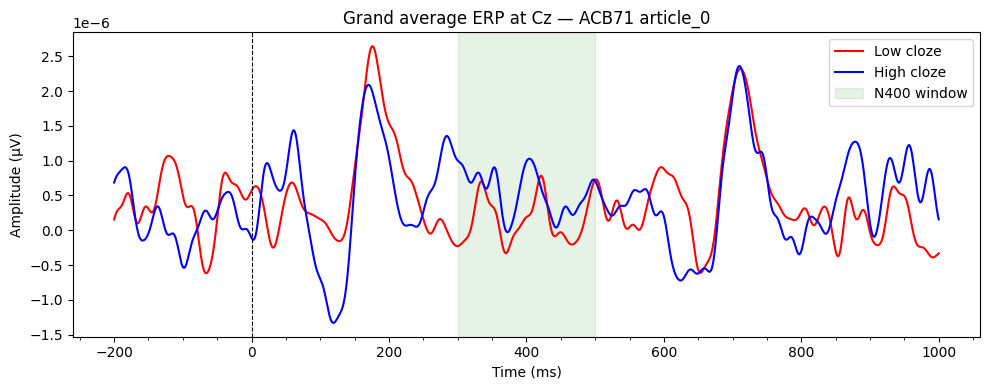

In [13]:
# ERP plot at Cz
from matplotlib.ticker import MultipleLocator

times = raw_ACB71_0.times * 1000  

low_mask  = (metadata_raw_ACB71_0['level'] == 'low').values
high_mask = (metadata_raw_ACB71_0['level'] == 'high').values

cz_idx = raw_ACB71_0.ch_names.index('Cz')

low_mean  = data_raw_ACB71_0[low_mask,  cz_idx, :].mean(axis=0)
high_mean = data_raw_ACB71_0[high_mask, cz_idx, :].mean(axis=0)

plt.figure(figsize=(10, 4))
ax = plt.gca()
plt.plot(times, low_mean,  label='Low cloze',  color='red')
plt.plot(times, high_mean, label='High cloze', color='blue')
plt.axvline(0,   color='black', linestyle='--', linewidth=0.8)
plt.axvspan(300, 500, alpha=0.1, color='green', label='N400 window')
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(50))
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (µV)')
plt.title('Grand average ERP at Cz — ACB71 article_0')
plt.legend()
plt.tight_layout()
plt.show()

# Load another FIF file

In [7]:

raw_WHR08_4 = mne.read_epochs(INPUTS_PATH / 'WHR08/article_4/preprocessed_epoch.fif', preload=True)


Reading /content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/WHR08/article_4/preprocessed_epoch.fif ...


/tmp/ipykernel_1043/2134251567.py:1: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/WHR08/article_4/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  raw_WHR08_4 = mne.read_epochs(INPUTS_PATH / 'WHR08/article_4/preprocessed_epoch.fif', preload=True)


    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 10 columns
618 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated


# Check the following: 
* shape: (n_epochs, n_channels, n_timepoints)
* time range: -200ms to +1000ms
* channel names are standard EEG labels 
* metadata has a `level` column 
* metadata has a `p_cloze` column
* value counts of `level`

In [15]:
print(raw_WHR08_4.info)
print(raw_WHR08_4.info.ch_names)

<Info | 11 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 lowpass: 45.0 Hz
 meas_date: 2023-11-14 13:38:04 UTC
 meas_id: 4 items (dict)
 nchan: 32
 projs: Average EEG reference: on
 sfreq: 1000.0 Hz
>
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']


In [11]:
metadata_raw_WHR08_4 = raw_WHR08_4.metadata
print(metadata_raw_WHR08_4.head())

          WordID       word  NumberOfLetters  WordFrequency  \
0  topic-4-00016   had_4_17                3           6.33   
1  topic-4-00017    to_4_18                2           7.43   
2  topic-4-00019   all_4_20                3           6.52   
3  topic-4-00020   the_4_21                3           7.73   
4  topic-4-00021  hard_4_22                4           5.53   

  OrthographicDistance BigramFrequency  ConsonantVowelProportion  Prediction  \
0                1.000             550                  0.666667        True   
1                1.150             269                  0.500000        True   
2                 None            None                  0.666667        True   
3                1.500             641                  0.666667        True   
4                1.150           1,542                  0.750000        True   

   p_cloze   level  
0     0.02     low  
1     0.17  medium  
2     0.11  medium  
3     0.73    high  
4     0.01     low  


In [12]:
print(metadata_raw_ACB71_0.info())

NameError: name 'metadata_raw_ACB71_0' is not defined

In [13]:
print(metadata_raw_WHR08_4.describe())

       NumberOfLetters  WordFrequency  ConsonantVowelProportion     p_cloze
count       618.000000     618.000000                618.000000  618.000000
mean          4.003236       5.955809                  0.596647    0.333172
std           1.939938       1.308244                  0.159561    0.350889
min           1.000000       1.670000                  0.000000    0.000000
25%           3.000000       5.032500                  0.500000    0.010000
50%           3.000000       6.110000                  0.666667    0.190000
75%           5.000000       6.980000                  0.666667    0.647500
max          12.000000       7.730000                  1.000000    1.000000


In [14]:
print(metadata_raw_WHR08_4[metadata_raw_WHR08_4['Prediction'] == False])

            WordID            word  NumberOfLetters  WordFrequency  \
106  topic-4-00139  farmer's_4_140                7           3.24   
144  topic-4-00188  farmer's_4_189                7           3.24   
290  topic-4-00352  farmer's_4_353                7           3.24   

    OrthographicDistance BigramFrequency  ConsonantVowelProportion  \
106                 None            None                  0.714286   
144                 None            None                  0.714286   
290                 None            None                  0.714286   

     Prediction  p_cloze   level  
106       False     0.16  medium  
144       False     0.47  medium  
290       False     0.16  medium  


In [15]:
print(metadata_raw_WHR08_4['Prediction'].value_counts())
print()
print(metadata_raw_WHR08_4['level'].value_counts())
print()
print(metadata_raw_WHR08_4[['level', 'p_cloze']].head(10))

Prediction
True     615
False      3
Name: count, dtype: int64

level
low       237
high      195
medium    186
Name: count, dtype: int64

    level  p_cloze
0     low     0.02
1  medium     0.17
2  medium     0.11
3    high     0.73
4     low     0.01
5  medium     0.31
6  medium     0.52
7     low     0.00
8     low     0.03
9     low     0.06


In [16]:
# Amplitude range (MNE stores EEG in volts instead of microvolts)
data_raw_WHR08_4 = raw_WHR08_4.get_data()
print(f"Shape: {data_raw_WHR08_4.shape}")
print(f"Min: {data_raw_WHR08_4.min()}")
print(f"Max: {data_raw_WHR08_4.max()}")
print(f"Mean: {data_raw_WHR08_4.mean()}")

Shape: (618, 32, 1201)
Min: -8.995189254257241e-05
Max: 0.00010902072249985295
Mean: -3.505823375295682e-24


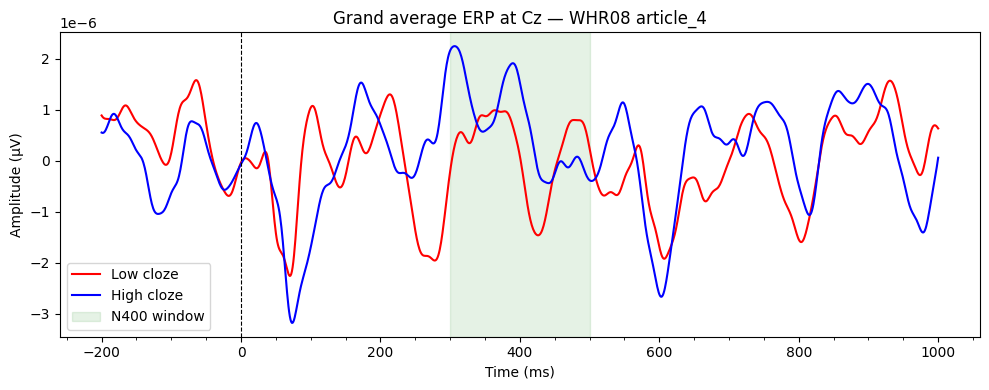

In [ ]:
# ERP plot at Cz
from matplotlib.ticker import MultipleLocator

times = raw_WHR08_4.times * 1000  

low_mask  = (metadata_raw_WHR08_4['level'] == 'low').values
high_mask = (metadata_raw_WHR08_4['level'] == 'high').values

cz_idx = raw_WHR08_4.ch_names.index('Cz')

low_mean  = data_raw_WHR08_4[low_mask,  cz_idx, :].mean(axis=0)
high_mean = data_raw_WHR08_4[high_mask, cz_idx, :].mean(axis=0)

plt.figure(figsize=(10, 4))
ax = plt.gca()
plt.plot(times, low_mean,  label='Low cloze',  color='red')
plt.plot(times, high_mean, label='High cloze', color='blue')
plt.axvline(0,   color='black', linestyle='--', linewidth=0.8)
plt.axvspan(300, 500, alpha=0.1, color='green', label='N400 window')
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(50))
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (µV)')
plt.title('Grand average ERP at Cz — WHR08 article_4')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
from pathlib import Path
from matplotlib.ticker import MultipleLocator
import mne
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
EPOCH_PATTERN = "*/article_*/preprocessed_epoch.fif"
CHANNEL = "Cz"

N400_MIN = 300
N400_MAX = 500

low_erps = []
high_erps = []
used_files = []

# -----------------------------
# Loop over all subject/article epoch files
# -----------------------------
epoch_files = sorted(INPUTS_PATH.glob(EPOCH_PATTERN))

for fpath in epoch_files:
    try:
        epochs = mne.read_epochs(fpath, preload=True, verbose=False)

        if epochs.metadata is None:
            print(f"Skipping {fpath}: no metadata")
            continue

        if "level" not in epochs.metadata.columns:
            print(f"Skipping {fpath}: no level column")
            continue

        if CHANNEL not in epochs.ch_names:
            print(f"Skipping {fpath}: no {CHANNEL} channel")
            continue

        data = epochs.get_data()  # shape: epochs x channels x time
        metadata = epochs.metadata
        times = epochs.times * 1000

        low_mask = (metadata["level"] == "low").values
        high_mask = (metadata["level"] == "high").values

        # Skip files that do not contain both conditions
        if low_mask.sum() == 0 or high_mask.sum() == 0:
            print(f"Skipping {fpath}: missing low or high trials")
            continue

        cz_idx = epochs.ch_names.index(CHANNEL)

        # Convert volts to microvolts
        low_mean = data[low_mask, cz_idx, :].mean(axis=0) * 1e6
        high_mean = data[high_mask, cz_idx, :].mean(axis=0) * 1e6

        low_erps.append(low_mean)
        high_erps.append(high_mean)
        used_files.append(fpath)

    except Exception as e:
        print(f"Could not read {fpath}: {e}")

print(f"Used {len(used_files)} files.")

# -----------------------------
# Grand average across files
# -----------------------------
low_grand = np.vstack(low_erps).mean(axis=0)
high_grand = np.vstack(high_erps).mean(axis=0)

# Optional: difference wave
diff_grand = low_grand - high_grand

# -----------------------------
# N400 mean amplitude
# -----------------------------
n400_mask = (times >= N400_MIN) & (times <= N400_MAX)

low_n400_mean = low_grand[n400_mask].mean()
high_n400_mean = high_grand[n400_mask].mean()
diff_n400_mean = diff_grand[n400_mask].mean()

print(f"Low cloze N400 mean:  {low_n400_mean:.3f} µV")
print(f"High cloze N400 mean: {high_n400_mean:.3f} µV")
print(f"Low - High N400 mean: {diff_n400_mean:.3f} µV")

/tmp/ipykernel_1043/2179026947.py:27: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(fpath, preload=True, verbose=False)
/tmp/ipykernel_1043/2179026947.py:27: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_1/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(fpath, preload=True, verbose=False)
/tmp/ipykernel_1043/2179026947.py:27: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experi

Used 100 files.
Low cloze N400 mean:  -0.258 µV
High cloze N400 mean: 0.241 µV
Low - High N400 mean: -0.499 µV


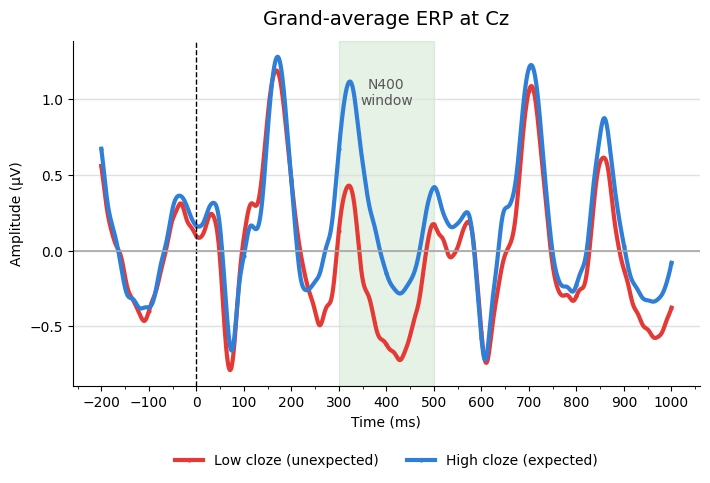

In [30]:
fig, ax = plt.subplots(figsize=(7.2, 5))

# Marker spacing
marker_every_ms = 100
step = max(1, int(marker_every_ms / np.diff(times).mean()))
marker_idx = np.arange(0, len(times), step)

ax.plot(
    times,
    low_grand,
    color="#e53935",
    linewidth=3,
    label="Low cloze (unexpected)",
    marker="o",
    markevery=marker_idx,
    markersize=2
)

ax.plot(
    times,
    high_grand,
    color="#2f7ed8",
    linewidth=3,
    label="High cloze (expected)",
    marker="o",
    markevery=marker_idx,
    markersize=2
)

# Reference lines
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="0.65", linewidth=1.2)

# N400 window
ax.axvspan(N400_MIN, N400_MAX, color="green", alpha=0.1, zorder=0)

ylim = ax.get_ylim()
ax.text(
    400,
    ylim[1] - 0.15 * (ylim[1] - ylim[0]),
    "N400\nwindow",
    color="#585757",
    ha="center",
    va="center",
    fontsize=10,
)

ax.set_title(f"Grand-average ERP at {CHANNEL}", fontsize=14, pad=12)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (µV)")

ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_minor_locator(MultipleLocator(50))

ax.grid(axis="y", color="0.88", linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

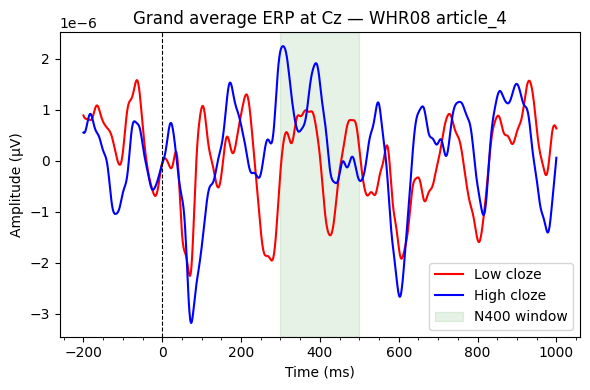

In [18]:
# ERP plot at Cz
from matplotlib.ticker import MultipleLocator

times = raw_WHR08_4.times * 1000  

low_mask  = (metadata_raw_WHR08_4['level'] == 'low').values
high_mask = (metadata_raw_WHR08_4['level'] == 'high').values

cz_idx = raw_WHR08_4.ch_names.index('Cz')

low_mean  = data_raw_WHR08_4[low_mask,  cz_idx, :].mean(axis=0)
high_mean = data_raw_WHR08_4[high_mask, cz_idx, :].mean(axis=0)

plt.figure(figsize=(6, 4))
ax = plt.gca()
plt.plot(times, low_mean,  label='Low cloze',  color='red')
plt.plot(times, high_mean, label='High cloze', color='blue')
plt.axvline(0,   color='black', linestyle='--', linewidth=0.8)
plt.axvspan(300, 500, alpha=0.1, color='green', label='N400 window')
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(50))
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (µV)')
plt.title('Grand average ERP at Cz — WHR08 article_4')
plt.legend()
plt.tight_layout()
plt.show()

## Low/High Class Balance 

In [23]:
import pandas as pd

counts = []

for subj in SUBJECTS:
    for art in range(5):
        path = INPUTS_PATH / subj / f"article_{art}" / 'preprocessed_epoch.fif'
        ep = mne.read_epochs(path, preload=False, verbose=False)
        meta = ep.metadata
        low  = (meta['level'] == 'low').sum()
        high = (meta['level'] == 'high').sum()
        counts.append({'subject': subj, 'article': art, 
                       'low': low, 'high': high})
        del ep

df = pd.DataFrame(counts)
per_subject = df.groupby('subject')[['low', 'high']].sum()
per_subject['total'] = per_subject['low'] + per_subject['high']
per_subject['balance'] = per_subject['low'] / per_subject['total']
print(per_subject.sort_values('total'))

/tmp/ipykernel_18232/3241522941.py:8: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_0/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  ep = mne.read_epochs(path, preload=False, verbose=False)
/tmp/ipykernel_18232/3241522941.py:8: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG_data/preprocessed/ACB71/article_1/preprocessed_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  ep = mne.read_epochs(path, preload=False, verbose=False)
/tmp/ipykernel_18232/3241522941.py:8: RuntimeWarning: This filename (/content/drive/MyDrive/Colab_Notebooks/DERCo/inputs/raw_fif/osfstorage/EEG-based Reading Experiment/EEG

         low  high  total   balance
subject                            
SIT48    588   627   1215  0.483951
MRB47    699   647   1346  0.519316
TRA37    722   693   1415  0.510247
LRK01    726   724   1450  0.500690
DGR11    790   734   1524  0.518373
WHR08    795   760   1555  0.511254
ACB71    781   779   1560  0.500641
JPY86    786   779   1565  0.502236
UJM92    814   774   1588  0.512594
MNY88    794   794   1588  0.500000
QPI83    839   772   1611  0.520795
QFT39    807   816   1623  0.497227
OLW10    830   801   1631  0.508890
WJX11    825   814   1639  0.503356
LYY64    853   834   1687  0.505631
HMK96    852   836   1688  0.504739
WAL74    852   838   1690  0.504142
NXB64    870   824   1694  0.513577
SAB93    856   850   1706  0.501758
RRO98    885   855   1740  0.508621


# Grand average ERP at Cz
Using the input of `X_0800` (28,265 epochs across 18 trainval subjects) and `y (each epoch is one word labeled 0 or 1)` now instead of a FIF file. 

NOTE: Multiply by 1e6 for microvolts (since the values are in bolts). Time axis: `np.linspace(0, 800, 801)`

1. Split all 28,265 epochs into two groups (high-cloze and low-cloze across subjects)
2. Average within each group at the Cz channel
3. Plot the resulting waveforms 
4. Confirm that the red is blow the blue in the 300-500 ms window across all 18 trainval subjects to confirm the N400 signal exists

In [24]:
X_0800_train = np.load(BASE_PATH / 'processed_data/train_val/X_0800.npy')
y_train = np.load(BASE_PATH / 'processed_data/train_val/y.npy')

print(X_0800_train.shape)
print(y_train.shape)


(28265, 32, 801)
(28265,)


In [25]:
low_cloze_epochs = X_0800_train[y_train == 0]
high_cloze_epochs = X_0800_train[y_train == 1]
print(low_cloze_epochs.shape)
print(high_cloze_epochs.shape)


(14331, 32, 801)
(13934, 32, 801)


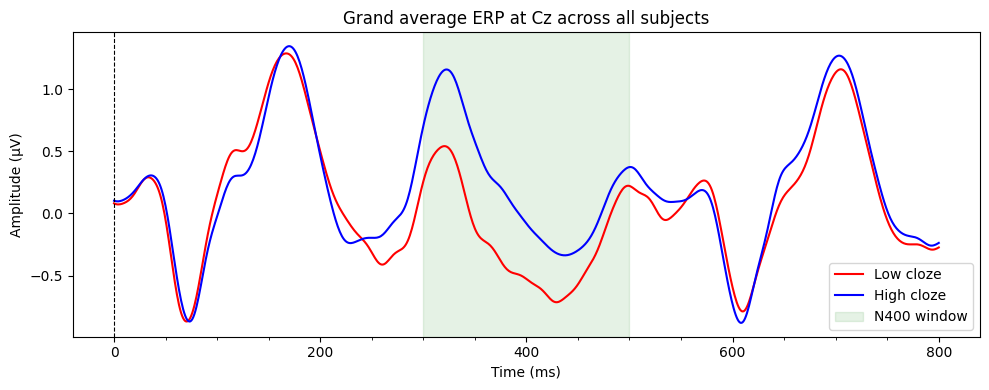

In [26]:
# Grand average ERP plot at Cz
from matplotlib.ticker import MultipleLocator
 
times = np.linspace(0, 800, 801)

low_grand_mean = low_cloze_epochs[:, CZ_INDEX, :].mean(axis=0)
high_grand_mean = high_cloze_epochs[:, CZ_INDEX, :].mean(axis=0)

plt.figure(figsize=(10, 4))
ax = plt.gca()
plt.plot(times, low_grand_mean * 1e6,  label='Low cloze',  color='red')
plt.plot(times, high_grand_mean * 1e6, label='High cloze', color='blue')
plt.axvline(0,   color='black', linestyle='--', linewidth=0.8)
plt.axvspan(300, 500, alpha=0.1, color='green', label='N400 window')
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.xaxis.set_minor_locator(MultipleLocator(50))
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (µV)')
plt.title('Grand average ERP at Cz across all subjects')
plt.legend()
plt.tight_layout()
plt.savefig(ANALYSIS_OUTPUTS_PATH / 'grand_average_cz_plot.png', dpi=300, )
plt.show()


# Class Balance Bar Chart

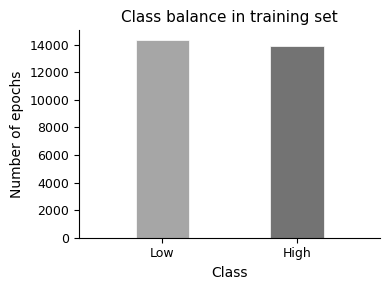

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_bal_df = pd.DataFrame({
    "Class": ["Low", "High"], 
    "Count": [
        (y_train==0).sum(), 
        (y_train==1).sum()
    ]
})

fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    class_bal_df["Class"], 
    class_bal_df["Count"], 
    color=["0.65", "0.45"], 
    edgecolor="white", 
    width=0.4,
    linewidth=0.5
)

ax.set_xlabel("Class", fontsize=10)
ax.set_ylabel("Number of epochs", fontsize=10)
ax.set_title("Class balance in training set", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)
ax.margins(x=0.3)

fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUTS_PATH / "class_balance_bar.png", dpi=300, bbox_inches=None)
fig.savefig(ANALYSIS_OUTPUTS_PATH / "class_balance_bar.pdf", bbox_inches=None)
plt.show()

# Per-Subject Epoch Count Bar Chart

In [28]:
import numpy as np
import pandas as pd

subj_train = np.load(BASE_PATH / 'processed_data/train_val/subjects.npy')

per_subj_epoch = {
    subj: {
        "total": (subj_train==subj).sum(),
        "low": (y_train[subj_train==subj]==0).sum(), 
        "high": (y_train[subj_train==subj]==1).sum()
    } 
    for subj in np.unique(subj_train)
}

per_subj_df = pd.DataFrame.from_dict(per_subj_epoch, orient='index').rename_axis('Subject').reset_index()
print(per_subj_df)

   Subject  total  low  high
0    DGR11   1524  790   734
1    HMK96   1688  852   836
2    JPY86   1565  786   779
3    LRK01   1450  726   724
4    LYY64   1687  853   834
5    MNY88   1588  794   794
6    MRB47   1346  699   647
7    NXB64   1694  870   824
8    OLW10   1631  830   801
9    QFT39   1623  807   816
10   QPI83   1611  839   772
11   RRO98   1740  885   855
12   SAB93   1706  856   850
13   SIT48   1215  588   627
14   TRA37   1415  722   693
15   UJM92   1588  814   774
16   WHR08   1555  795   760
17   WJX11   1639  825   814


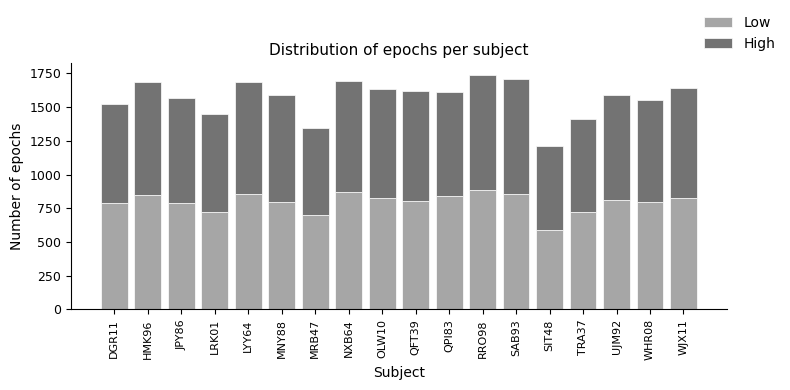

In [29]:
import numpy as np
import matplotlib.pyplot as plt

per_subj_epoch = {
    subj: {
        "total": (subj_train==subj).sum(),
        "low": (y_train[subj_train==subj]==0).sum(), 
        "high": (y_train[subj_train==subj]==1).sum()
    } 
    for subj in np.unique(subj_train)
}

per_subj_df = (
    pd.DataFrame.from_dict(per_subj_epoch, orient='index')
    .rename_axis("Subject")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(per_subj_df))

ax.bar(
    x, 
    per_subj_df['low'], 
    label="Low", 
    color="0.65", 
    edgecolor="white", 
    linewidth=0.5
)
ax.bar(
    x, 
    per_subj_df['high'],
    bottom=per_subj_df['low'], 
    label="High", 
    color="0.45", 
    edgecolor="white", 
    linewidth=0.5
)

ax.set_xlabel("Subject", fontsize=10)
ax.set_ylabel("Number of epochs", fontsize=10)
ax.set_title("Distribution of epochs per subject", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(per_subj_df["Subject"], rotation=90, fontsize=8)
ax.tick_params(axis="y", labelsize=9)

ax.legend(
    frameon=False, 
    loc="lower center", 
    bbox_to_anchor=(1.02, 1), 
    ncol=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(ANALYSIS_OUTPUTS_PATH / "per_subject_epoch_counts_bargraph.png", dpi=300, bbox_inches="tight")
fig.savefig(ANALYSIS_OUTPUTS_PATH / "per_subject_epoch_counts_bargraph.pdf", bbox_inches="tight")
fig.show()

# Scalp Topography

Shows which electrodes are most active at a specific timepoint (at 400 ms there should be a centro-parietal pattern for the N400). Data is fro the low minus high cloze voltage difference at 400 ms post-stimulus onset averaged across 18 trainval subjects. Blue indicates greater negativity for low-cloze words. Blue should be maximal over centro-parietal electrodez (Cz, CP1, CP2, Pz). 
Using MNE's `plot_topomap`, must have a vector of amplitude values (one per channel) and an `info` object containing electrode positions. 
1. Load one FIF briefly just to extract the info object, then close it. 
2. Extract the `info` object from that FIF because `plot_topomap` needs the specific phsyical lotation (on the scalp) of each of the 32 electrodes (defined by the 10-20 system). 
3. Take average over epochs for the `low_cloze_epochs` and `high_cloze_epochs` previously created to get the mean response at each of the 32 channels across the index that corresponds to 400 ms.
4. Compute the difference for the N400 contrast like so: `diff = low_all_channels[:, 400] - high_all_channels[:, 400]` to get a shape of (32,). 


In [10]:
sample_fif = raw_ACB71_0 # Already loaded this before
info = sample_fif.info
print(info)

<Info | 11 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 lowpass: 45.0 Hz
 meas_date: 2023-12-20 13:02:16 UTC
 meas_id: 4 items (dict)
 nchan: 32
 projs: Average EEG reference: on
 sfreq: 1000.0 Hz
>


In [31]:
# Nevermind - won't need this because plot_topomap reads electrode positions directly from info 
channel_df = pd.DataFrame(info['chs'])
print(channel_df.info())
channel_loc_df = channel_df[['loc', 'ch_name']].copy()
channel_loc_df[['X', 'Y', 'Z']] = pd.DataFrame(
    [i[:3] for i in channel_loc_df['loc']], 
    index=channel_loc_df.index
)
channel_loc_df = channel_loc_df.drop(columns="loc")
print(channel_loc_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scanno       32 non-null     int64  
 1   logno        32 non-null     int64  
 2   kind         32 non-null     int64  
 3   range        32 non-null     float64
 4   cal          32 non-null     float64
 5   coil_type    32 non-null     int64  
 6   loc          32 non-null     object 
 7   unit         32 non-null     int64  
 8   unit_mul     32 non-null     int64  
 9   ch_name      32 non-null     object 
 10  coord_frame  32 non-null     int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 2.9+ KB
None
   ch_name         X         Y         Z
0      Fp1 -0.030903  0.114585  0.027867
1       Fz -0.001229  0.093274  0.102639
2       F3 -0.051809  0.086688  0.078714
3       F7 -0.071877  0.073104  0.025790
4      FT9 -0.085797  0.043082 -0.011576
5      FC5 -0.078906  0.051367  0.0629

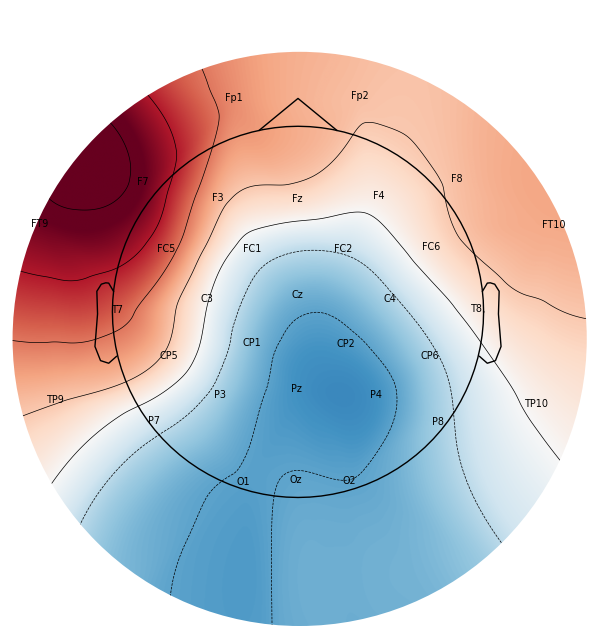

In [ ]:
low_all_channels = low_cloze_epochs[:,:,N400_INDEX].mean(axis=0)
high_all_channels = high_cloze_epochs[:,:,N400_INDEX].mean(axis=0)
diff = low_all_channels - high_all_channels
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams['lines.markersize'] = .1
mne.viz.plot_topomap(
    data=diff, 
    pos=info, 
    ch_type='eeg', 
    names=ch_names, 
    size=8, 
    sensors='k.',
    sphere='eeg',
    image_interp='cubic', 
    res=1024, 
    axes=ax
)
fig.savefig(ANALYSIS_OUTPUTS_PATH / "scalp_topograph.pdf")
fig.savefig(ANALYSIS_OUTPUTS_PATH / "scalp_topograph.svg")

plt.rcParams['lines.markersize'] = 6 # restore to default
